In [2]:
# Lab 3: Different Types of Data Analysis

# !pip install seaborn plotly pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("🎯 Lab 3: Exploring Different Types of Data")
print("📋 Dataset: Titanic Dataset")
print("=" * 50)

# =============================================================================
# LOAD DATASET
# =============================================================================

# Load Titanic dataset (built into seaborn)
titanic_df = sns.load_dataset('titanic')

# Create additional variables to demonstrate different data types
np.random.seed(42)

# Add temperature data (Interval - Celsius, no true zero)
titanic_df['cabin_temp_celsius'] = np.random.normal(18, 3, len(titanic_df))

# Add ticket price in modern dollars (Ratio - has true zero)
titanic_df['ticket_price_usd'] = titanic_df['fare'] * 20  # Convert to modern equivalent

# Create ordinal education levels
education_mapping = {0: 'No Education', 1: 'Primary', 2: 'Secondary', 3: 'Higher Education'}
titanic_df['education_level'] = np.random.choice([0, 1, 2, 3], len(titanic_df), p=[0.4, 0.3, 0.2, 0.1])
titanic_df['education_level'] = titanic_df['education_level'].map(education_mapping)

print("✅ Dataset Loaded and Enhanced:")
print(f"Shape: {titanic_df.shape}")
print("\nFirst 5 rows:")
print(titanic_df[['sex', 'class', 'education_level', 'cabin_temp_celsius', 'age', 'ticket_price_usd']].head())

🎯 Lab 3: Exploring Different Types of Data
📋 Dataset: Titanic Dataset
✅ Dataset Loaded and Enhanced:
Shape: (891, 18)

First 5 rows:
      sex  class education_level  cabin_temp_celsius   age  ticket_price_usd
0    male  Third         Primary           19.490142  22.0           145.000
1  female  First         Primary           17.585207  38.0          1425.666
2  female  Third         Primary           19.943066  26.0           158.500
3  female  First       Secondary           22.569090  35.0          1062.000
4    male  Third    No Education           17.297540  35.0           161.000



📊 1. NOMINAL DATA ANALYSIS
----------------------------------------
🏷️ Nominal Variables: ['sex', 'embarked', 'class', 'who']
Characteristics: Categories with NO inherent order or ranking

Sex categories: ['male' 'female']

Embarked categories: ['S' 'C' 'Q' nan]


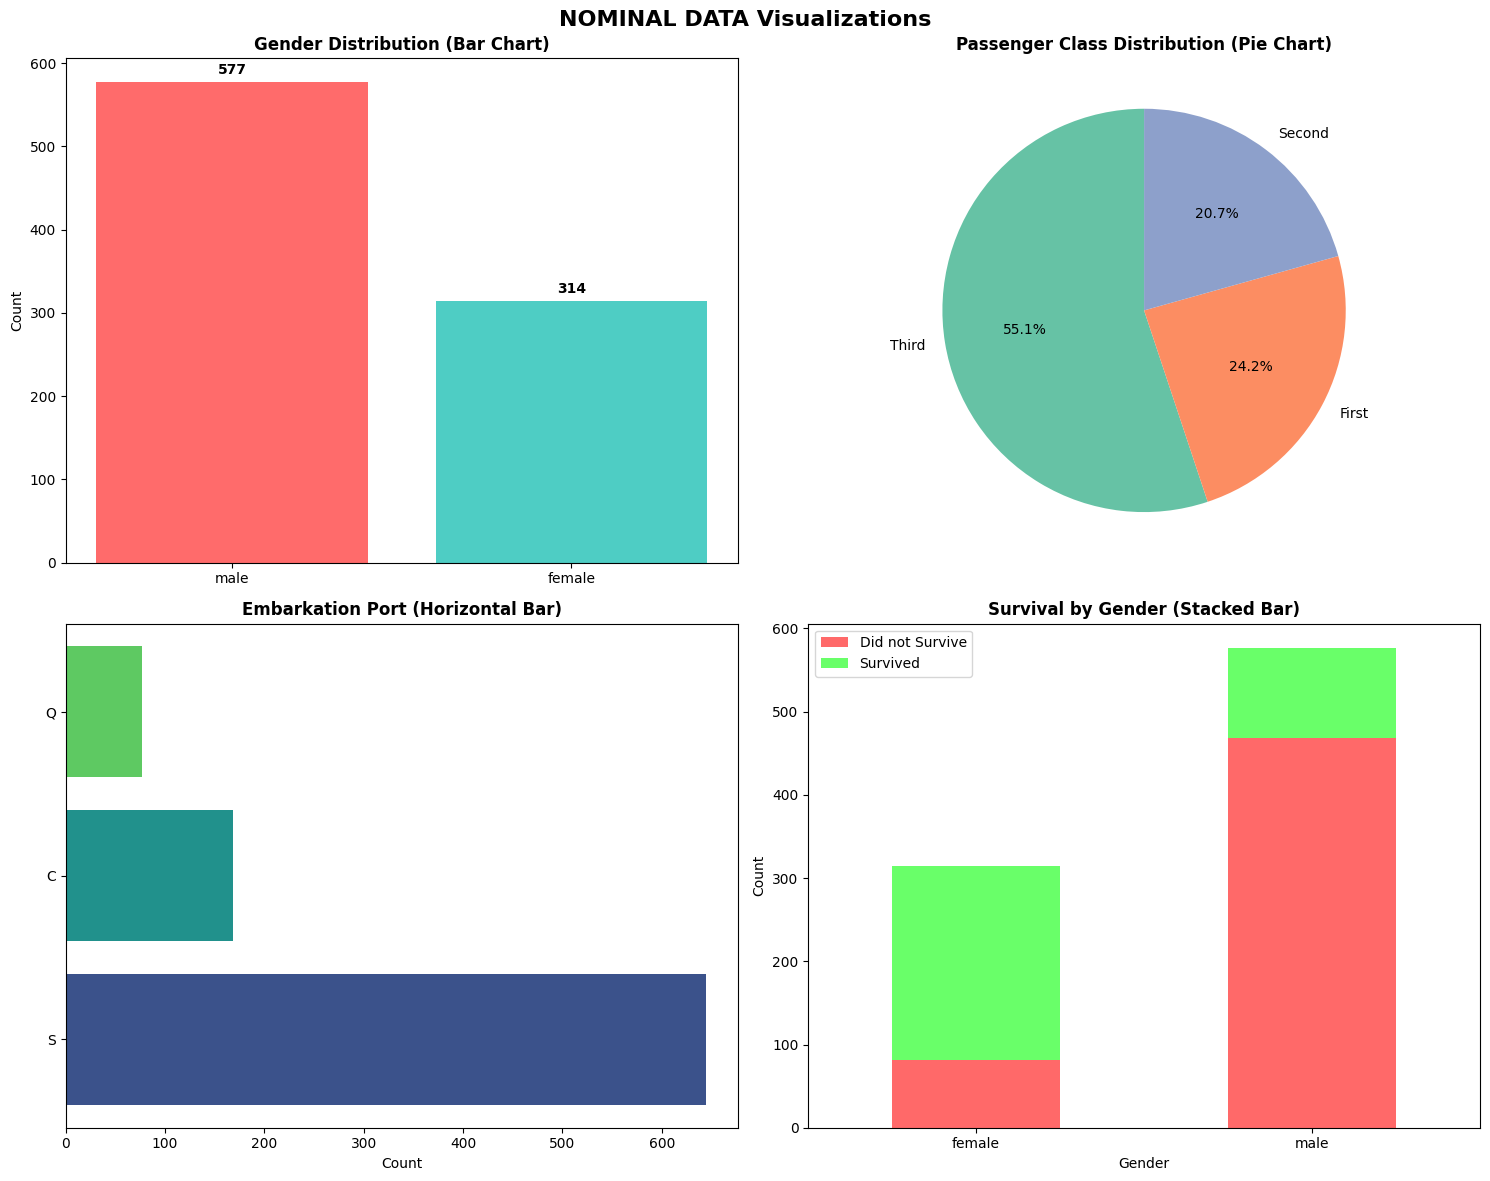


✨ Nominal Data Key Points:
• No mathematical operations meaningful (can't average 'male' and 'female')
• Only mode (most frequent) makes sense as central tendency
• Visualized with bar charts, pie charts - avoid gradients or size encoding!


In [3]:

# =============================================================================
# 1. NOMINAL DATA ANALYSIS
# =============================================================================

print("\n📊 1. NOMINAL DATA ANALYSIS")
print("-" * 40)

# Nominal variables: Categorical with no inherent order
nominal_vars = ['sex', 'embarked', 'class', 'who']
print(f"🏷️ Nominal Variables: {nominal_vars}")
print("Characteristics: Categories with NO inherent order or ranking")

# Show unique values
for var in nominal_vars[:2]:  # Show first 2 for space
    print(f"\n{var.title()} categories: {titanic_df[var].unique()}")

# Create visualizations for nominal data
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('NOMINAL DATA Visualizations', fontsize=16, fontweight='bold', y=0.98)

# 1. Bar Chart - Gender Distribution
sex_counts = titanic_df['sex'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0, 0].bar(sex_counts.index, sex_counts.values, color=colors)
axes[0, 0].set_title('Gender Distribution (Bar Chart)', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Pie Chart - Passenger Class
class_counts = titanic_df['class'].value_counts()
axes[0, 1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=sns.color_palette("Set2", len(class_counts)))
axes[0, 1].set_title('Passenger Class Distribution (Pie Chart)', fontweight='bold')

# 3. Horizontal Bar Chart - Embarkation Port
embarked_counts = titanic_df['embarked'].value_counts()
axes[1, 0].barh(embarked_counts.index, embarked_counts.values, 
                color=sns.color_palette("viridis", len(embarked_counts)))
axes[1, 0].set_title('Embarkation Port (Horizontal Bar)', fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Stacked Bar - Survival by Gender (shows relationship)
survival_gender = pd.crosstab(titanic_df['sex'], titanic_df['survived'])
survival_gender.plot(kind='bar', stacked=True, ax=axes[1, 1], 
                    color=['#FF4444', '#44FF44'], alpha=0.8)
axes[1, 1].set_title('Survival by Gender (Stacked Bar)', fontweight='bold')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Did not Survive', 'Survived'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n✨ Nominal Data Key Points:")
print("• No mathematical operations meaningful (can't average 'male' and 'female')")
print("• Only mode (most frequent) makes sense as central tendency")
print("• Visualized with bar charts, pie charts - avoid gradients or size encoding!")


📊 2. ORDINAL DATA ANALYSIS
----------------------------------------
🏷️ Ordinal Variables: ['education_level', 'class']
Characteristics: Categories WITH meaningful order/ranking

Education Level Order: ['No Education', 'Primary', 'Secondary', 'Higher Education']
Class Order (economic): ['Third', 'Second', 'First']


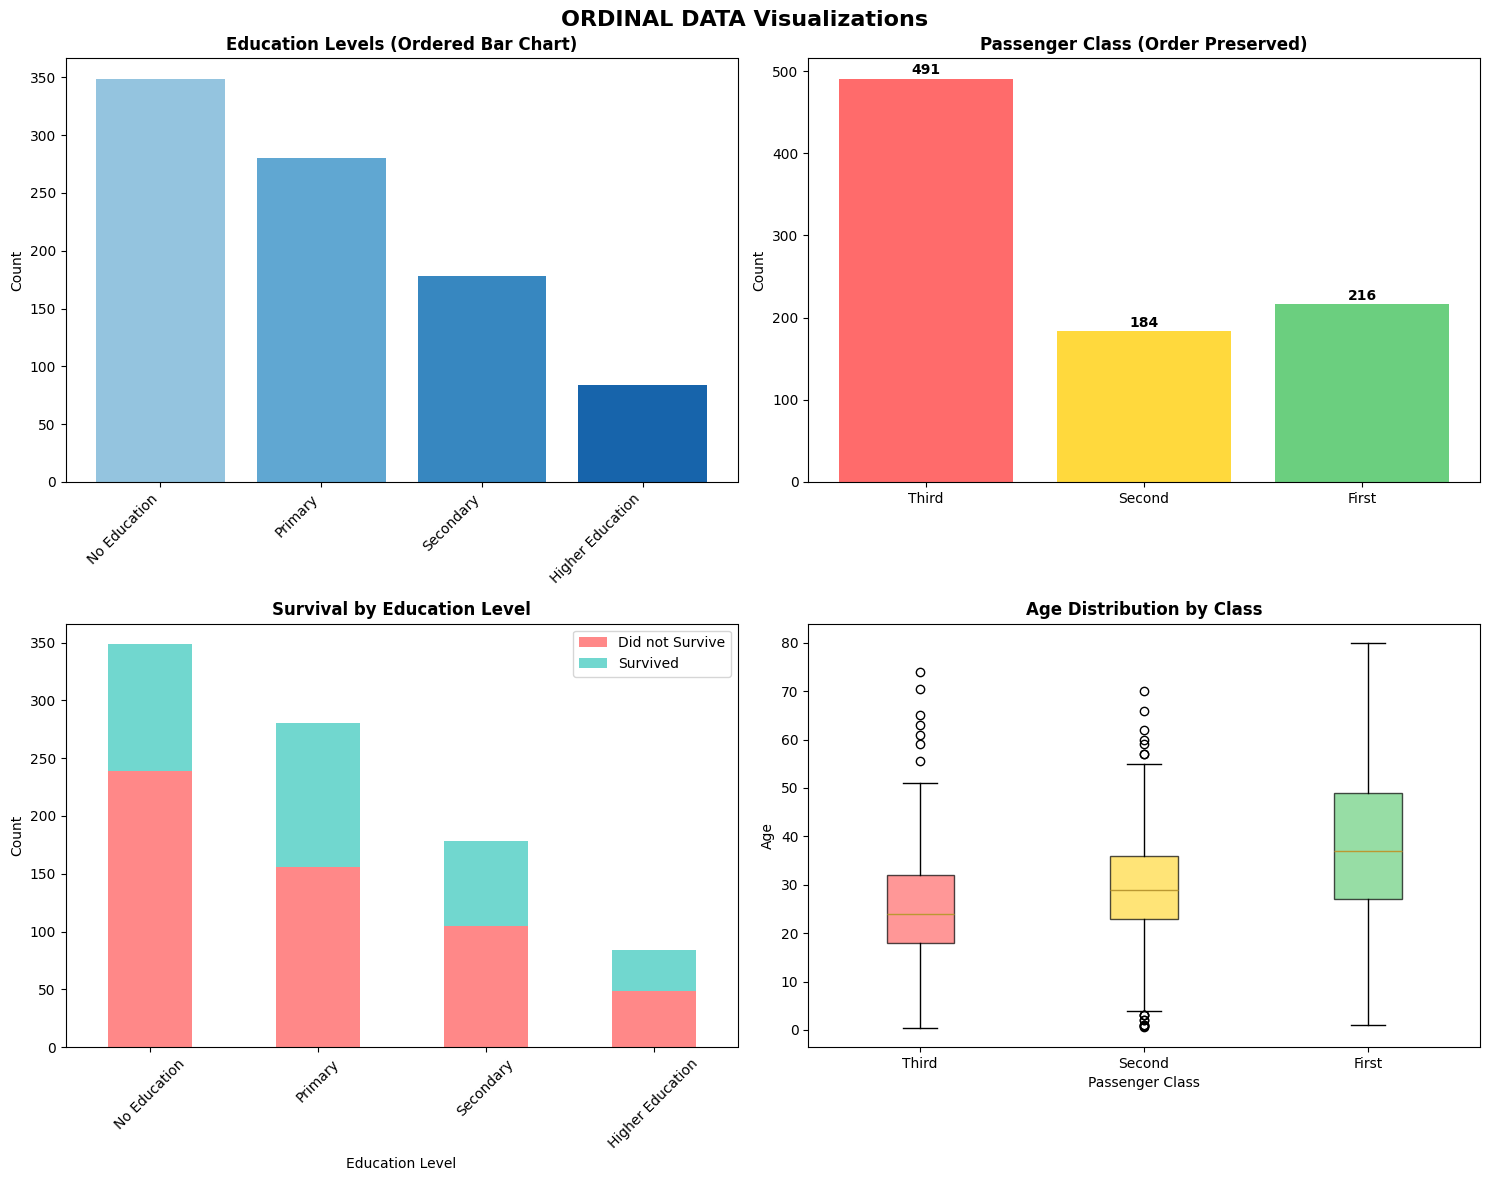


✨ Ordinal Data Key Points:
• Order matters! 'First Class' > 'Second Class' > 'Third Class'
• Can use median, but mean might be misleading
• Visualizations preserve order - use gradients/sequential colors


In [4]:


# =============================================================================
# 2. ORDINAL DATA ANALYSIS  
# =============================================================================

print("\n📊 2. ORDINAL DATA ANALYSIS")
print("-" * 40)

# Ordinal variables: Categorical WITH meaningful order
ordinal_vars = ['education_level', 'class']
print(f"🏷️ Ordinal Variables: {ordinal_vars}")
print("Characteristics: Categories WITH meaningful order/ranking")

# Define proper order for ordinal variables
education_order = ['No Education', 'Primary', 'Secondary', 'Higher Education']
class_order = ['Third', 'Second', 'First']

print(f"\nEducation Level Order: {education_order}")
print(f"Class Order (economic): {class_order}")

# Create ordinal visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ORDINAL DATA Visualizations', fontsize=16, fontweight='bold', y=0.98)

# 1. Ordered Bar Chart - Education Levels
education_counts = titanic_df['education_level'].value_counts().reindex(education_order)
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.8, len(education_counts)))
axes[0, 0].bar(range(len(education_counts)), education_counts.values, color=colors_grad)
axes[0, 0].set_title('Education Levels (Ordered Bar Chart)', fontweight='bold')
axes[0, 0].set_xticks(range(len(education_counts)))
axes[0, 0].set_xticklabels(education_counts.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Count')

# 2. Class Distribution with Order Preserved
class_counts = titanic_df['class'].value_counts().reindex(class_order)
colors_class = ['#FF6B6B', '#FFD93D', '#6BCF7F']  # Red to Green showing progression
axes[0, 1].bar(class_counts.index, class_counts.values, color=colors_class)
axes[0, 1].set_title('Passenger Class (Order Preserved)', fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0, 1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3. Stacked Bar showing Survival by Education (ordered)
education_survival = pd.crosstab(titanic_df['education_level'], titanic_df['survived'])
education_survival = education_survival.reindex(education_order)
education_survival.plot(kind='bar', stacked=True, ax=axes[1, 0],
                       color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[1, 0].set_title('Survival by Education Level', fontweight='bold')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['Did not Survive', 'Survived'])
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Box plot showing Age distribution by Class (ordinal)
class_mapping = {'First': 1, 'Second': 2, 'Third': 3}
titanic_df['class_numeric'] = titanic_df['class'].map(class_mapping)
titanic_df_clean = titanic_df.dropna(subset=['age'])

box_data = [titanic_df_clean[titanic_df_clean['class'] == cls]['age'].values 
           for cls in class_order]
bp = axes[1, 1].boxplot(box_data, labels=class_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_class):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Age Distribution by Class', fontweight='bold')
axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print("\n✨ Ordinal Data Key Points:")
print("• Order matters! 'First Class' > 'Second Class' > 'Third Class'")
print("• Can use median, but mean might be misleading")
print("• Visualizations preserve order - use gradients/sequential colors")



📊 3. INTERVAL DATA ANALYSIS
----------------------------------------
🏷️ Interval Variable: cabin_temp_celsius
Characteristics: Numeric with equal intervals, NO true zero
• 0°C doesn't mean 'no temperature' - it's just freezing point of water
• 20°C is NOT twice as hot as 10°C!

Temperature Statistics:
count    891.000000
mean      18.038395
std        2.945383
min        8.276198
25%       16.044845
50%       18.039006
75%       19.925953
max       29.558194
Name: cabin_temp_celsius, dtype: float64


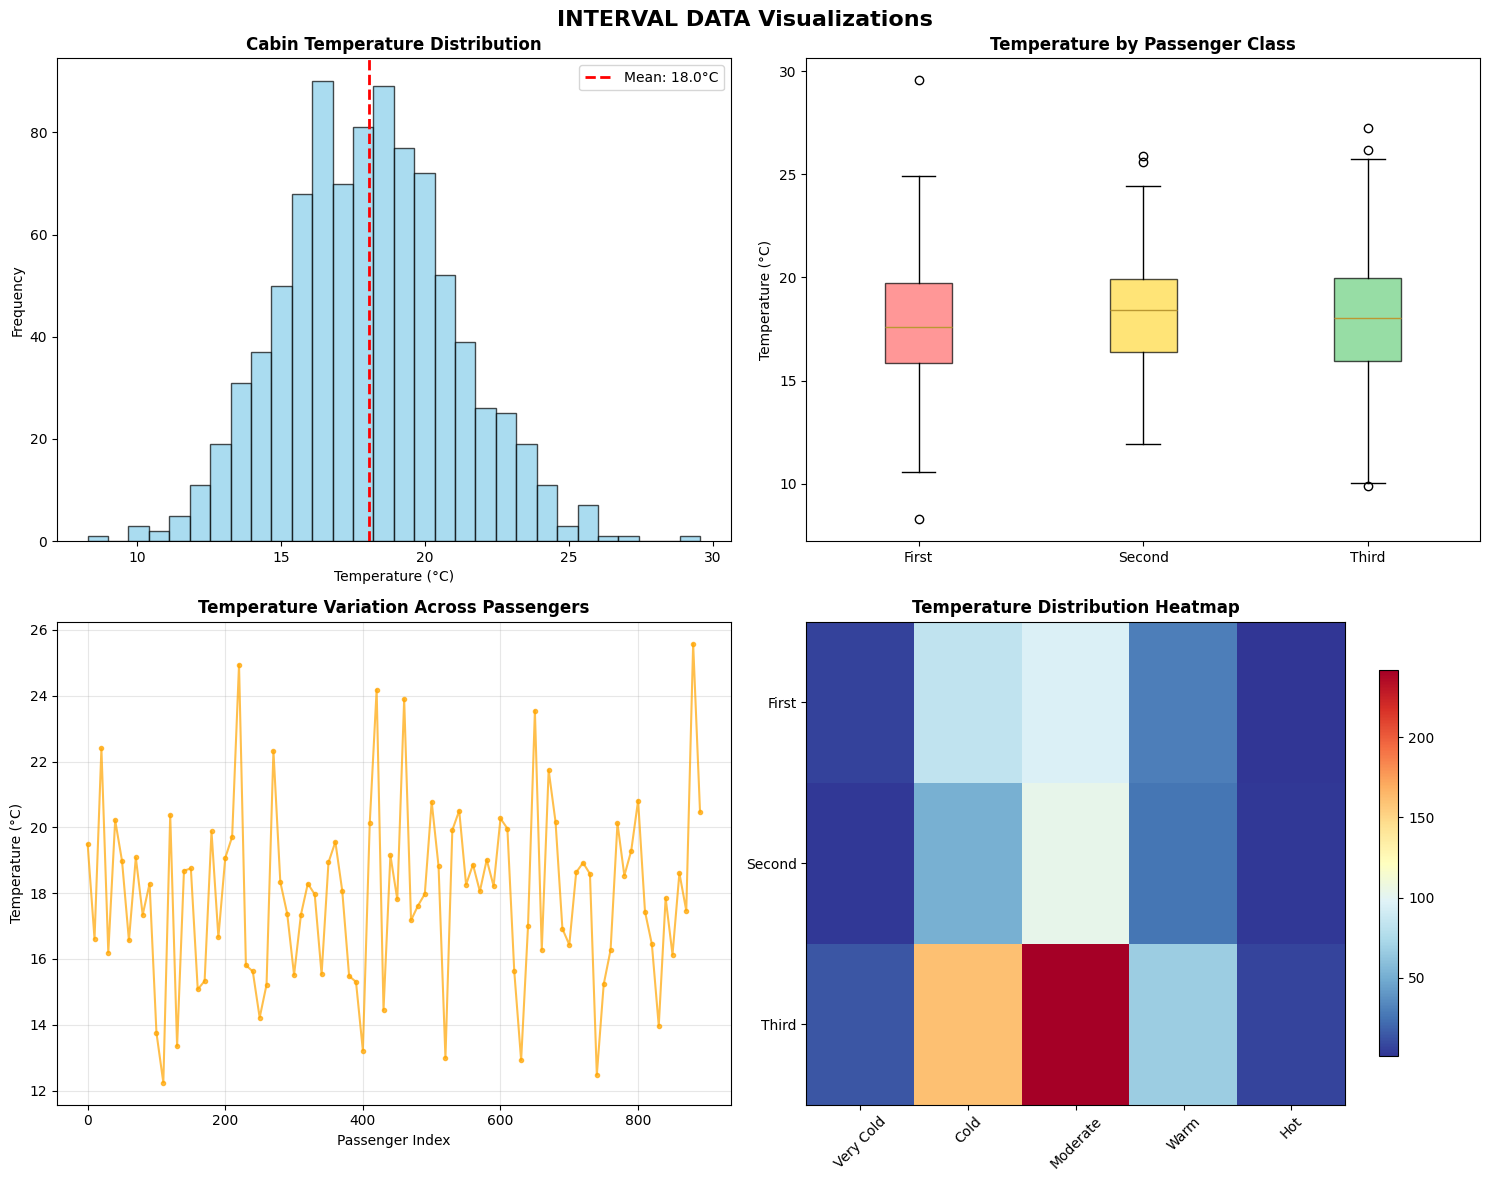


✨ Interval Data Key Points:
• Equal intervals: difference between 15°C and 20°C = difference between 20°C and 25°C
• NO true zero: 0°C is arbitrary (freezing point), not absence of temperature
• Can calculate mean, median, standard deviation
• Cannot say '20°C is twice as hot as 10°C' - ratios meaningless!


In [5]:

# =============================================================================
# 3. INTERVAL DATA ANALYSIS
# =============================================================================

print("\n📊 3. INTERVAL DATA ANALYSIS")
print("-" * 40)

interval_var = 'cabin_temp_celsius'
print(f"🏷️ Interval Variable: {interval_var}")
print("Characteristics: Numeric with equal intervals, NO true zero")
print("• 0°C doesn't mean 'no temperature' - it's just freezing point of water")
print("• 20°C is NOT twice as hot as 10°C!")

# Display statistics
temp_stats = titanic_df[interval_var].describe()
print(f"\nTemperature Statistics:\n{temp_stats}")

# Create interval data visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('INTERVAL DATA Visualizations', fontsize=16, fontweight='bold', y=0.98)

# 1. Histogram with density curve
axes[0, 0].hist(titanic_df[interval_var], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(titanic_df[interval_var].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {titanic_df[interval_var].mean():.1f}°C')
axes[0, 0].set_title('Cabin Temperature Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Box plot by passenger class
temp_by_class = [titanic_df[titanic_df['class'] == cls][interval_var].values 
                for cls in ['First', 'Second', 'Third']]
bp = axes[0, 1].boxplot(temp_by_class, labels=['First', 'Second', 'Third'], patch_artist=True)
colors = ['#FF6B6B', '#FFD93D', '#6BCF7F']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_title('Temperature by Passenger Class', fontweight='bold')
axes[0, 1].set_ylabel('Temperature (°C)')

# 3. Line plot showing temperature "progression" (simulated by passenger index)
# Sample every 10th passenger for cleaner visualization
sample_indices = range(0, len(titanic_df), 10)
sample_temps = titanic_df.iloc[sample_indices][interval_var].values
axes[1, 0].plot(sample_indices, sample_temps, marker='o', markersize=3, alpha=0.7, color='orange')
axes[1, 0].set_title('Temperature Variation Across Passengers', fontweight='bold')
axes[1, 0].set_xlabel('Passenger Index')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Heatmap showing temperature ranges
# Create temperature bins for heatmap
temp_bins = pd.cut(titanic_df[interval_var], bins=5, labels=['Very Cold', 'Cold', 'Moderate', 'Warm', 'Hot'])
temp_class_cross = pd.crosstab(titanic_df['class'], temp_bins)
im = axes[1, 1].imshow(temp_class_cross.values, cmap='RdYlBu_r', aspect='auto')
axes[1, 1].set_title('Temperature Distribution Heatmap', fontweight='bold')
axes[1, 1].set_xticks(range(len(temp_class_cross.columns)))
axes[1, 1].set_xticklabels(temp_class_cross.columns, rotation=45)
axes[1, 1].set_yticks(range(len(temp_class_cross.index)))
axes[1, 1].set_yticklabels(temp_class_cross.index)
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

plt.tight_layout()
plt.show()

print("\n✨ Interval Data Key Points:")
print("• Equal intervals: difference between 15°C and 20°C = difference between 20°C and 25°C")
print("• NO true zero: 0°C is arbitrary (freezing point), not absence of temperature")
print("• Can calculate mean, median, standard deviation")
print("• Cannot say '20°C is twice as hot as 10°C' - ratios meaningless!")


📊 4. RATIO DATA ANALYSIS
----------------------------------------
🏷️ Ratio Variables: ['age', 'ticket_price_usd']
Characteristics: Numeric with equal intervals AND true zero
• 0 age = no age (birth), 0 price = free
• Ratios meaningful: $200 ticket is twice as expensive as $100 ticket

Age Statistics:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

Ticket Price Statistics:
count      714.00000
mean       693.89028
std       1058.37859
min          0.00000
25%        161.00000
50%        314.83400
75%        667.50000
max      10246.58400
Name: ticket_price_usd, dtype: float64


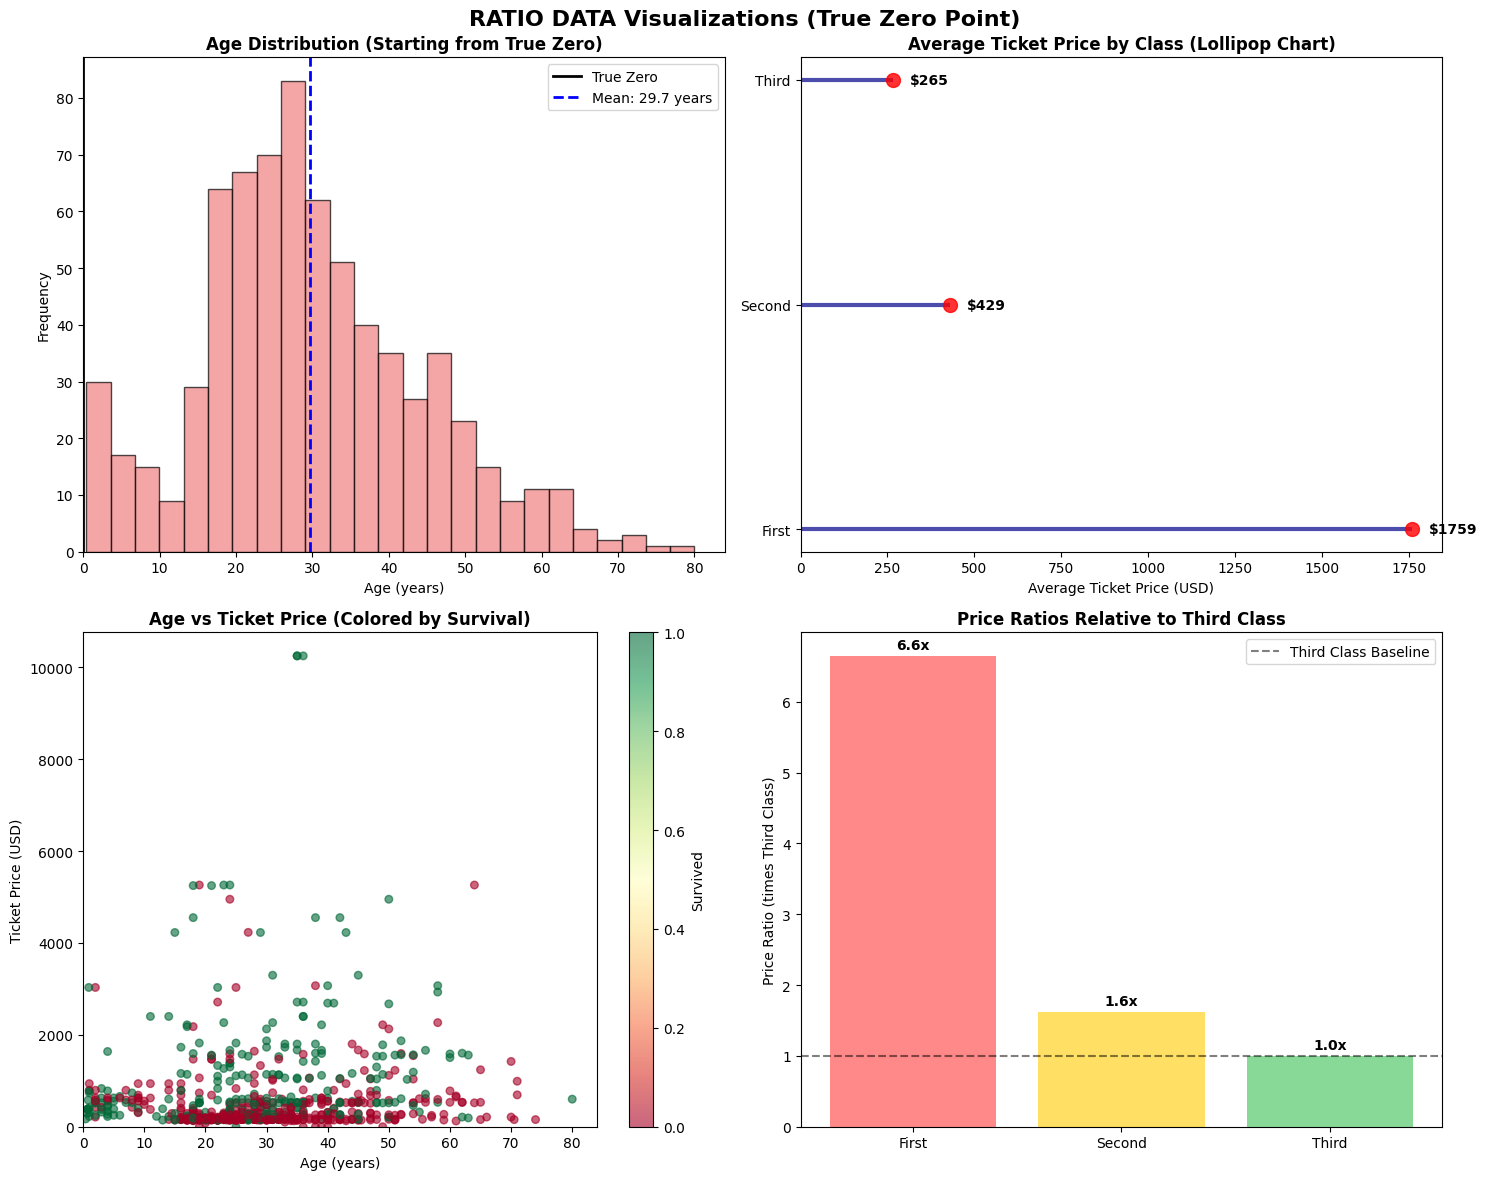


✨ Ratio Data Key Points:
• True zero exists: 0 years = birth, $0 = free
• Ratios meaningful: 40 years IS twice 20 years
• All statistical measures valid (mean, median, mode, std dev)
• Visualizations should show the zero baseline when meaningful

📋 COMPREHENSIVE SUMMARY
Data Type Example Variable Order Matters? Equal Intervals? True Zero? Ratios Meaningful? Best Central Tendency Best Visualization
  Nominal     Gender (sex)             No               No         No                 No                  Mode      Bar/Pie Chart
  Ordinal  Education Level            Yes               No         No                 No                Median        Ordered Bar
 Interval Temperature (°C)            Yes              Yes         No                 No           Mean/Median     Histogram/Line
    Ratio      Age (years)            Yes              Yes        Yes                Yes                  Mean  Histogram/Scatter


In [6]:






# =============================================================================
# 4. RATIO DATA ANALYSIS
# =============================================================================

print("\n📊 4. RATIO DATA ANALYSIS")
print("-" * 40)

ratio_vars = ['age', 'ticket_price_usd']
print(f"🏷️ Ratio Variables: {ratio_vars}")
print("Characteristics: Numeric with equal intervals AND true zero")
print("• 0 age = no age (birth), 0 price = free")
print("• Ratios meaningful: $200 ticket is twice as expensive as $100 ticket")

# Clean data for ratio analysis
ratio_df = titanic_df.dropna(subset=['age', 'ticket_price_usd'])
print(f"\nAge Statistics:\n{ratio_df['age'].describe()}")
print(f"\nTicket Price Statistics:\n{ratio_df['ticket_price_usd'].describe()}")

# Create ratio data visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('RATIO DATA Visualizations (True Zero Point)', fontsize=16, fontweight='bold', y=0.98)

# 1. Histogram starting from zero (emphasizing true zero)
axes[0, 0].hist(ratio_df['age'], bins=25, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=2, label='True Zero')
axes[0, 0].axvline(ratio_df['age'].mean(), color='blue', linestyle='--', linewidth=2, 
                  label=f'Mean: {ratio_df["age"].mean():.1f} years')
axes[0, 0].set_title('Age Distribution (Starting from True Zero)', fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, None)  # Start from zero
axes[0, 0].legend()

# 2. Lollipop chart for average ticket price by class
avg_price_by_class = ratio_df.groupby('class')['ticket_price_usd'].mean().sort_values(ascending=False)
y_pos = range(len(avg_price_by_class))
axes[0, 1].hlines(y_pos, 0, avg_price_by_class.values, colors='darkblue', alpha=0.7, linewidth=3)
axes[0, 1].scatter(avg_price_by_class.values, y_pos, color='red', s=100, alpha=0.8, zorder=2)
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(avg_price_by_class.index)
axes[0, 1].set_xlabel('Average Ticket Price (USD)')
axes[0, 1].set_title('Average Ticket Price by Class (Lollipop Chart)', fontweight='bold')
axes[0, 1].set_xlim(0, None)  # Start from zero baseline
for i, v in enumerate(avg_price_by_class.values):
    axes[0, 1].text(v + 50, i, f'${v:.0f}', va='center', fontweight='bold')

# 3. Scatter plot showing relationship between two ratio variables
scatter = axes[1, 0].scatter(ratio_df['age'], ratio_df['ticket_price_usd'], 
                           c=ratio_df['survived'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Ticket Price (USD)')
axes[1, 0].set_title('Age vs Ticket Price (Colored by Survival)', fontweight='bold')
axes[1, 0].set_xlim(0, None)
axes[1, 0].set_ylim(0, None)
plt.colorbar(scatter, ax=axes[1, 0], label='Survived')

# 4. Bar chart with meaningful ratios shown
class_ratios = avg_price_by_class / avg_price_by_class.min()  # Ratio to cheapest class
axes[1, 1].bar(class_ratios.index, class_ratios.values, 
               color=['#FF6B6B', '#FFD93D', '#6BCF7F'], alpha=0.8)
axes[1, 1].set_title('Price Ratios Relative to Third Class', fontweight='bold')
axes[1, 1].set_ylabel('Price Ratio (times Third Class)')
axes[1, 1].set_ylim(0, None)
axes[1, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Third Class Baseline')
for i, v in enumerate(class_ratios.values):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}x', ha='center', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n✨ Ratio Data Key Points:")
print("• True zero exists: 0 years = birth, $0 = free")
print("• Ratios meaningful: 40 years IS twice 20 years")
print("• All statistical measures valid (mean, median, mode, std dev)")
print("• Visualizations should show the zero baseline when meaningful")

# =============================================================================
# SUMMARY COMPARISON
# =============================================================================

print("\n📋 COMPREHENSIVE SUMMARY")
print("=" * 60)

summary_data = {
    'Data Type': ['Nominal', 'Ordinal', 'Interval', 'Ratio'],
    'Example Variable': ['Gender (sex)', 'Education Level', 'Temperature (°C)', 'Age (years)'],
    'Order Matters?': ['No', 'Yes', 'Yes', 'Yes'],
    'Equal Intervals?': ['No', 'No', 'Yes', 'Yes'],
    'True Zero?': ['No', 'No', 'No', 'Yes'],
    'Ratios Meaningful?': ['No', 'No', 'No', 'Yes'],
    'Best Central Tendency': ['Mode', 'Median', 'Mean/Median', 'Mean'],
    'Best Visualization': ['Bar/Pie Chart', 'Ordered Bar', 'Histogram/Line', 'Histogram/Scatter']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))